# Interactive detrending model explorer

Load a cleaned Stage 1 `SpecData.h5`, compare every detrending model supported by the pipeline, optionally add one or more Gaussian components, and save the selected model and parameter values for an individual-fit YAML. Run the cells from top to bottom.

In [6]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import yaml

# Change these paths before running the remaining cells.
DATA_PATH = Path('/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b_real/step1/eclipse2/miriam/eclipse2_eureka_miriam_trimmed_SpecData.h5')
REPOSITORY_ROOT = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / 'pipeline').is_dir()), Path.cwd())
SOURCE_CONFIG_PATH = None  # Optional: Path('/path/to/existing_individual_fit.yaml')
OUTPUT_CONFIG_PATH = Path('selected_detrending_model.yaml')
NORMALIZE = 'median'
SIGMA_CLIP = 4.0

if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
from pipeline.utils.io import load_photometry_dataset, preprocess_dataset
from pipeline.utils.models import detec_model


Loaded 1886 integrations from /home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b_real/step1/eclipse2/miriam/eclipse2_eureka_miriam_trimmed_SpecData.h5
Time is expressed in hours from MJD 61256.40118334


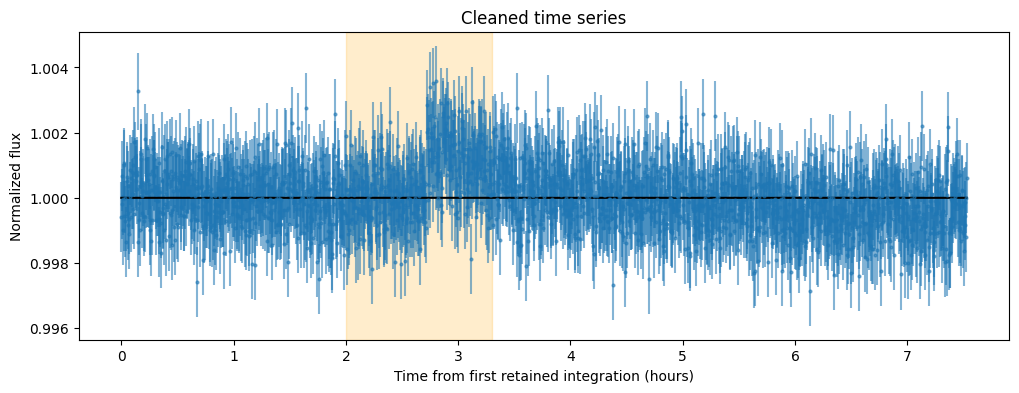

In [7]:
raw = load_photometry_dataset(DATA_PATH)
data = preprocess_dataset(raw, normalize=NORMALIZE, sigma_clip=SIGMA_CLIP)
time = data['time_hours']
flux = data['flux']
flux_err = data['flux_err']
centroid_x = data['centroid_x']
centroid_y = data['centroid_y']
print(f"Loaded {data['n_points']} integrations from {DATA_PATH}")
print(f"Time is expressed in hours from MJD {data['time_mjd'][0]:.8f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(time, flux, yerr=flux_err, fmt='.', ms=4, color='tab:blue', alpha=0.55)
ax.set(xlabel='Time from first retained integration (hours)', ylabel='Normalized flux', title='Cleaned time series')
ax.axvspan(2, 3.3, color='orange', alpha=0.2, label='Window')
plt.plot(time, np.ones_like(time), color='black')
plt.show()


## Interactive model

Gaussian components are **added** to the selected baseline. Choose no Gaussian, one Gaussian, or a two-mode Gaussian. You can also add a one- or two-peak asymmetric stellar flare. The single flare retains a visually fixed peak time. The double flare is two independent models, each with its own `F0`, amplitude, peak time, rise timescale, and decay timescale; all ten values are saved as MCMC initial values. The residual panel shows `flux − model`; RMS and BIC are provided as quick comparison aids, not as substitutes for the full eclipse fit.

In [8]:
BASE_MODELS = ['exp', 'linear', 'polynomial', 'double_exp', 'exp+linear', 'exp+polynomial', 'linear+polynomial']
duration = max(float(np.ptp(time)), 1e-6)
cadence = max(float(np.nanmedian(np.diff(np.unique(time)))), duration / 1000)
scatter = max(float(np.nanstd(flux)), 1e-5)
trend_scale = float(np.clip(0.5 * np.ptp(np.nanpercentile(flux, [5, 95])), 1e-4, 0.1))

def fs(description, value, minimum, maximum, step=None):
    if step is None:
        step = (maximum - minimum) / 500
    return widgets.FloatSlider(description=description, value=float(np.clip(value, minimum, maximum)),
                               min=float(minimum), max=float(maximum), step=float(step),
                               continuous_update=False, readout_format='.6g',
                               style={'description_width': '135px'}, layout=widgets.Layout(width='650px'))

def base_parameter_widgets(name):
    slope = 0.2 / duration
    rate = 10.0 / duration
    definitions = {
        # Both amplitude and rate must be nonzero for the exponential curvature to be visible.
        'exp': [('exp amplitude', trend_scale, -0.2, 0.2), ('exp rate', 1.0/duration, -rate, rate), ('exp offset', float(np.nanmedian(flux)) - trend_scale, 0.8, 1.2)],
        'linear': [('linear slope', 0, -slope, slope), ('linear intercept', 1, 0.8, 1.2)],
        'polynomial': [('cubic coefficient', 0, -0.2/duration**3, 0.2/duration**3), ('quadratic coefficient', 0, -0.2/duration**2, 0.2/duration**2), ('linear coefficient', 0, -slope, slope), ('constant', 1, 0.8, 1.2)],
        'double_exp': [('exp1 amplitude', .5, -.2, 1.2), ('exp1 rate', 0, -rate, rate), ('exp2 amplitude', .5, -.2, 1.2), ('exp2 rate', 0, -rate, rate)],
    }
    if name == 'exp+linear':
        defs = definitions['exp'] + definitions['linear']
    elif name == 'exp+polynomial':
        defs = definitions['exp'] + definitions['polynomial']
    elif name == 'linear+polynomial':
        defs = definitions['linear'] + definitions['polynomial']
    else:
        defs = definitions[name]
    return [fs(*definition) for definition in defs]

model_dropdown = widgets.Dropdown(options=BASE_MODELS, value='exp', description='Baseline')
gaussian_count = widgets.Dropdown(
    options=[('No Gaussian', 0), ('Single Gaussian', 1), ('Two-mode Gaussian', 2)],
    value=0, description='Gaussian model',
    style={'description_width': '120px'}, layout=widgets.Layout(width='300px'),
)
flare_count = widgets.Dropdown(
    options=[('No flare', 0), ('Single-peak flare', 1), ('Double-peak flare', 2)],
    value=0, description='Flare model',
    style={'description_width': '90px'}, layout=widgets.Layout(width='270px'),
)
parameter_box = widgets.VBox()
plot_output = widgets.Output()
save_button = widgets.Button(description='Save for individual fit', button_style='success', icon='save')
save_output = widgets.Output()
current_sliders = []
flare_peak_sliders = []

def selected_model_type():
    count = gaussian_count.value
    model_type = model_dropdown.value if count == 0 else f"{model_dropdown.value}+{count if count > 1 else ''}gaussian"
    count = flare_count.value
    return f"{model_type}+{count if count > 1 else ''}flare" if count else model_type

def update_plot(change=None):
    parameters = np.array([slider.value for slider in current_sliders])
    model = detec_model(
        time, centroid_x, centroid_y, parameters, selected_model_type()
    )
    residuals = flux - model
    finite = np.isfinite(residuals)
    rms = np.sqrt(np.mean(residuals[finite] ** 2)) if finite.any() else np.nan
    sigma2 = max(rms**2, np.finfo(float).tiny)
    bic = len(parameters) * np.log(max(finite.sum(), 1)) + finite.sum() * np.log(sigma2)
    with plot_output:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
        axes[0].errorbar(time, flux, yerr=flux_err, fmt='.', ms=4, color='0.45', alpha=.45, label='Cleaned flux')
        axes[0].plot(time, model, color='tab:red', lw=2.3, label=selected_model_type())
        axes[0].set_ylabel('Normalized flux'); axes[0].legend(loc='best')
        axes[0].set_title(f'RMS = {rms:.6g}     BIC = {bic:.2f}')
        axes[1].axhline(0, color='black', lw=1)
        axes[1].scatter(time, residuals, s=10, color='tab:blue', alpha=.65)
        axes[1].set(xlabel='Time from first retained integration (hours)', ylabel='Residual')
        plt.show()

def rebuild_controls(change=None):
    global current_sliders, flare_peak_sliders
    current_sliders = base_parameter_widgets(model_dropdown.value)
    displayed_sliders = list(current_sliders)
    count = gaussian_count.value
    for index in range(count):
        center_fraction = 0.5 if count == 1 else (index + 1) / (count + 1)
        initial_center = float(np.nanmin(time) + center_fraction * duration)
        gaussian_sliders = [
            fs(f'G{index+1} amplitude', trend_scale / max(count, 1), -5*scatter, 5*scatter),
            fs(f'G{index+1} center (hr)', initial_center, float(np.nanmin(time)), float(np.nanmax(time))),
            fs(f'G{index+1} sigma (hr)', max(duration/20, cadence), cadence, duration, step=max(cadence/5, duration/5000)),
        ]
        current_sliders.extend(gaussian_sliders)
        displayed_sliders.extend(gaussian_sliders)
    flare_peak_sliders = []
    flare_modes = flare_count.value
    if flare_modes:
        peak_separation = max(2 * cadence, duration / 100)
        for index in range(flare_modes):
            initial_peak = float(np.nanmedian(time) + (index - (flare_modes - 1) / 2) * peak_separation)
            flare_f0 = fs(f'F{index+1} F0', 0.0, -5*scatter, 5*scatter)
            flare_amplitude = fs(f'F{index+1} amplitude', trend_scale / flare_modes, -5*scatter, 5*scatter)
            flare_peak = fs(f'F{index+1} peak (hr)', initial_peak, float(np.nanmin(time)), float(np.nanmax(time)))
            flare_rise = fs(f'F{index+1} rise tau (hr)', max(duration/20, cadence), cadence, duration)
            flare_decay = fs(f'F{index+1} decay tau (hr)', max(duration/5, cadence), cadence, duration)
            current_sliders.extend([
                flare_f0, flare_amplitude, flare_peak, flare_rise, flare_decay
            ])
            flare_peak_sliders.append(flare_peak)
            displayed_sliders.extend([flare_f0, flare_amplitude, flare_peak, flare_rise, flare_decay])
    for slider in current_sliders:
        slider.observe(update_plot, names='value')
    parameter_box.children = displayed_sliders
    update_plot()

def save_selection(button):
    detrending = {'model_type': selected_model_type(), 'initial_guess': [float(s.value) for s in current_sliders]}
    source = Path(SOURCE_CONFIG_PATH) if SOURCE_CONFIG_PATH else None
    if source is not None:
        with source.open('r', encoding='utf-8') as stream:
            saved = yaml.safe_load(stream) or {}
        saved['detrending'] = detrending
    else:
        saved = {'detrending': detrending}
    output = Path(OUTPUT_CONFIG_PATH)
    output.parent.mkdir(parents=True, exist_ok=True)
    with output.open('w', encoding='utf-8') as stream:
        yaml.safe_dump(saved, stream, sort_keys=False)
    with save_output:
        clear_output(wait=True)
        print(f'Saved {output.resolve()}')
        print(yaml.safe_dump({'detrending': detrending}, sort_keys=False))

model_dropdown.observe(rebuild_controls, names='value')
gaussian_count.observe(rebuild_controls, names='value')
flare_count.observe(rebuild_controls, names='value')
save_button.on_click(save_selection)
display(widgets.HBox([model_dropdown, gaussian_count, flare_count]), parameter_box, plot_output, save_button, save_output)
rebuild_controls()


VBox()

Output()

Button(button_style='success', description='Save for individual fit', icon='save', style=ButtonStyle())

Output()

## Fit two flare peaks independently

Choose a separate fitting window around each peak. Each window is fitted with its own complete asymmetric flare model (`F0`, amplitude, peak time, rise time, and decay time). Select either the quick least-squares method or a windowed MCMC fit. In MCMC mode, every flare parameter can have a uniform prior (lower/upper), Gaussian prior (mean/sigma), or fixed value; fixed parameters are not sampled. The upper plot shows the two independent fits in different colours, the middle plot shows the selected baseline plus both flare models added together, and the bottom plot shows the combined-model residuals. Select `None` to use an adjustable constant offset, or choose any supported baseline. The reported vector is ordered for `<baseline>+2flare` in the individual-fit YAML.

In [10]:
from scipy.optimize import least_squares
import emcee
from pipeline.utils.models import stellar_flare_func

separate_baseline = widgets.Dropdown(options=['None'] + BASE_MODELS, value='exp', description='Baseline')
time_min, time_max = float(np.nanmin(time)), float(np.nanmax(time))
quarter = max(duration / 4, 2 * cadence)
window_widgets = [
    fs('Peak 1 window start', time_min, time_min, time_max),
    fs('Peak 1 window end', min(time_min + 2 * quarter, time_max), time_min, time_max),
    fs('Peak 2 window start', max(time_max - 2 * quarter, time_min), time_min, time_max),
    fs('Peak 2 window end', time_max, time_min, time_max),
]
separate_baseline_box = widgets.VBox()
separate_flare_box = widgets.VBox()
separate_plot_output = widgets.Output()
separate_result_output = widgets.Output()
flare_fit_method = widgets.Dropdown(
    options=[('Least squares', 'least_squares'), ('MCMC', 'mcmc')],
    value='least_squares', description='Fit method',
)
mcmc_walkers = widgets.IntText(value=32, description='Walkers')
mcmc_steps = widgets.IntText(value=2000, description='Steps')
mcmc_burn = widgets.IntText(value=500, description='Burn-in')
mcmc_settings_box = widgets.HBox([mcmc_walkers, mcmc_steps, mcmc_burn])
flare_prior_box = widgets.VBox()
fit_separate_button = widgets.Button(description='Fit both peaks independently', button_style='primary')
separate_none_offset = fs('Constant offset', float(np.nanmedian(flux)), 0.8, 1.2)
separate_baseline_sliders = []
separate_flare_sliders = []
separate_flare_covariances = [None, None]

def separate_baseline_model():
    if separate_baseline.value == 'None':
        return np.full_like(time, separate_none_offset.value, dtype=float)
    pars = np.array([slider.value for slider in separate_baseline_sliders])
    return detec_model(time, centroid_x, centroid_y, pars, separate_baseline.value)

def independent_flare_values(index):
    sliders = separate_flare_sliders[index]
    return np.array([slider.value for slider in sliders], dtype=float)

def draw_independent_flares(change=None):
    if len(separate_flare_sliders) != 2:
        return
    baseline = separate_baseline_model()
    flare1 = stellar_flare_func(time, *independent_flare_values(0))
    flare2 = stellar_flare_func(time, *independent_flare_values(1))
    windows = [(window_widgets[0].value, window_widgets[1].value),
               (window_widgets[2].value, window_widgets[3].value)]
    masks = [(time >= start) & (time <= end) for start, end in windows]
    model1 = np.where(masks[0], baseline + flare1, np.nan)
    model2 = np.where(masks[1], baseline + flare2, np.nan)
    windowed_flare1 = np.where(masks[0], flare1, 0.0)
    windowed_flare2 = np.where(masks[1], flare2, 0.0)
    combined = baseline + windowed_flare1 + windowed_flare2
    residuals = flux - combined
    with separate_plot_output:
        clear_output(wait=True)
        fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 3, 1.4]})
        for ax in axes[:2]:
            ax.errorbar(time, flux, yerr=flux_err, fmt='.', ms=4, color='0.45', alpha=.4, label='Cleaned flux')
        axes[0].plot(time, model1, color='tab:orange', lw=2.2, label='Independent flare 1 fit')
        axes[0].plot(time, model2, color='tab:green', lw=2.2, label='Independent flare 2 fit')
        axes[0].set_ylabel('Normalized flux')
        axes[0].set_title('Two completely separate flare fits')
        axes[0].legend(loc='best')
        axes[1].plot(time, combined, color='tab:red', lw=2.3, label='Baseline + flare 1 + flare 2')
        axes[1].set(xlabel='Time from first retained integration (hours)', ylabel='Normalized flux', title='Added flare model')
        axes[1].legend(loc='best')
        axes[2].axhline(0, color='black', lw=1)
        axes[2].errorbar(time, residuals, yerr=flux_err, fmt='.', ms=4, color='tab:blue', alpha=.6)
        axes[2].set(xlabel='Time from first retained integration (hours)', ylabel='Residual',
                    title='Residuals: flux − combined model')
        for index, (start, end) in enumerate(windows):
            for axis_index, ax in enumerate(axes):
                ax.axvspan(start, end, color=['tab:orange', 'tab:green'][index], alpha=.10,
                           label=f'Flare {index + 1} fitting window' if axis_index == 0 else '_nolegend_')
        axes[0].legend(loc='best')
        axes[0].set_xlim(2, 3.5)
        plt.tight_layout()
        plt.show()

def rebuild_separate_baseline(change=None):
    global separate_baseline_sliders
    separate_baseline_sliders = [] if separate_baseline.value == 'None' else base_parameter_widgets(separate_baseline.value)
    for slider in separate_baseline_sliders:
        slider.observe(draw_independent_flares, names='value')
    separate_baseline_box.children = ([separate_none_offset] if separate_baseline.value == 'None'
                                      else separate_baseline_sliders)
    draw_independent_flares()

def make_independent_flare_sliders(index, center):
    sliders = [
        fs(f'F{index} F0', 0.0, -5 * scatter, 5 * scatter),
        fs(f'F{index} amplitude', trend_scale / 2, -5 * scatter, 5 * scatter),
        fs(f'F{index} peak (hr)', center, time_min, time_max),
        fs(f'F{index} rise tau (hr)', max(duration / 20, cadence), cadence, duration),
        fs(f'F{index} decay tau (hr)', max(duration / 5, cadence), cadence, duration),
    ]
    for slider in sliders:
        slider.observe(draw_independent_flares, names='value')
    return sliders

def fit_one_flare(index, start, end, baseline):
    if start >= end:
        raise ValueError(f'Peak {index + 1}: window start must be before window end')
    mask = np.isfinite(time) & np.isfinite(flux) & (time >= start) & (time <= end)
    if mask.sum() < 6:
        raise ValueError(f'Peak {index + 1}: fitting window contains fewer than six points')
    local_time = time[mask]
    target = flux[mask] - baseline[mask]
    error = np.where(np.isfinite(flux_err[mask]) & (flux_err[mask] > 0), flux_err[mask], np.nanmedian(flux_err[mask]))
    initial = independent_flare_values(index)
    initial[2] = np.clip(initial[2], start, end)
    tau_floor = max(cadence / 10, np.finfo(float).eps)
    lower = np.array([-10 * scatter, -10 * scatter, start, tau_floor, tau_floor])
    upper = np.array([10 * scatter, 10 * scatter, end, duration, duration])
    def residuals(pars):
        return (target - stellar_flare_func(local_time, *pars)) / error
    result = least_squares(residuals, np.clip(initial, lower, upper), bounds=(lower, upper))
    degrees_of_freedom = max(mask.sum() - result.x.size, 1)
    reduced_chi2 = 2.0 * result.cost / degrees_of_freedom
    covariance = np.linalg.pinv(result.jac.T @ result.jac) * reduced_chi2
    return result.x, covariance

def fit_independent_flares_least_squares(button=None):
    global separate_flare_covariances
    baseline = separate_baseline_model()
    windows = [(window_widgets[0].value, window_widgets[1].value),
               (window_widgets[2].value, window_widgets[3].value)]
    with separate_result_output:
        clear_output(wait=True)
        try:
            results = [fit_one_flare(i, *windows[i], baseline) for i in range(2)]
            fitted = [result[0] for result in results]
            separate_flare_covariances = [result[1] for result in results]
            for sliders, values in zip(separate_flare_sliders, fitted):
                for slider, value in zip(sliders, values):
                    slider.value = float(value)
            baseline_values = ([float(separate_none_offset.value)] if separate_baseline.value == 'None'
                               else [float(s.value) for s in separate_baseline_sliders])
            initial_guess = baseline_values + fitted[0].tolist() + fitted[1].tolist()
            model_name = '2flare' if separate_baseline.value == 'None' else f'{separate_baseline.value}+2flare'
            print(f'MCMC starting model: {model_name}')
            print('Each flare above was fitted only to its selected time window.')
            print('initial_guess:')
            print(yaml.safe_dump(initial_guess, default_flow_style=True).strip())
        except Exception as exc:
            print(f'Fit failed: {exc}')
    draw_independent_flares()

FLARE_PARAMETER_NAMES = ['F0', 'amplitude', 'peak', 'tau_rise', 'tau_decay']
flare_prior_controls = []

def make_prior_control(flare_index, parameter_index, initial_value):
    name = FLARE_PARAMETER_NAMES[parameter_index]
    if name == 'F0':
        kind, first, second = 'fixed', initial_value, 0.0
    elif name == 'amplitude':
        kind, first, second = 'uniform', -10 * scatter, 10 * scatter
    elif name == 'peak':
        kind = 'uniform'
        first = float(window_widgets[2 * flare_index].value)
        second = float(window_widgets[2 * flare_index + 1].value)
    else:
        kind, first, second = 'uniform', max(cadence / 10, np.finfo(float).eps), duration
    prior_kind = widgets.Dropdown(
        options=[('Uniform', 'uniform'), ('Gaussian', 'gaussian'), ('Fixed', 'fixed')],
        value=kind, layout=widgets.Layout(width='125px'),
    )
    first_value = widgets.FloatText(value=float(first), layout=widgets.Layout(width='145px'))
    second_value = widgets.FloatText(value=float(second), layout=widgets.Layout(width='145px'))
    label = widgets.HTML(
        value=f'<b>Flare {flare_index + 1} {name}</b>', layout=widgets.Layout(width='180px')
    )
    return {'kind': prior_kind, 'first': first_value, 'second': second_value,
            'row': widgets.HBox([label, prior_kind, first_value, second_value])}

def read_prior_specs(flare_index):
    specs = []
    for parameter_name, controls in zip(FLARE_PARAMETER_NAMES, flare_prior_controls[flare_index]):
        kind = controls['kind'].value
        first = float(controls['first'].value)
        second = float(controls['second'].value)
        if kind == 'uniform' and not first < second:
            raise ValueError(f'Flare {flare_index + 1} {parameter_name}: uniform lower bound must be below upper bound')
        if kind == 'gaussian' and not second > 0:
            raise ValueError(f'Flare {flare_index + 1} {parameter_name}: Gaussian sigma must be positive')
        specs.append((kind, first, second))
    return specs

def fit_one_flare_mcmc(index, start, end, baseline):
    if start >= end:
        raise ValueError(f'Peak {index + 1}: window start must be before window end')
    mask = np.isfinite(time) & np.isfinite(flux) & (time >= start) & (time <= end)
    if mask.sum() < 6:
        raise ValueError(f'Peak {index + 1}: fitting window contains fewer than six points')
    local_time = time[mask]
    target = flux[mask] - baseline[mask]
    local_error = np.asarray(flux_err[mask], dtype=float)
    valid_error = np.isfinite(local_error) & (local_error > 0)
    fallback = np.nanmedian(local_error[valid_error]) if valid_error.any() else max(scatter, 1e-12)
    error = np.where(valid_error, local_error, fallback)
    specs = read_prior_specs(index)
    free_indices = [i for i, spec in enumerate(specs) if spec[0] != 'fixed']
    fixed_parameters = np.array([spec[1] for spec in specs], dtype=float)
    if not free_indices:
        return fixed_parameters, np.zeros((5, 5)), fixed_parameters, fixed_parameters

    def unpack(free_parameters):
        full = fixed_parameters.copy()
        full[free_indices] = free_parameters
        return full

    def log_probability(free_parameters):
        full = unpack(free_parameters)
        if not np.all(np.isfinite(full)) or full[3] <= 0 or full[4] <= 0:
            return -np.inf
        log_prior = 0.0
        for value, parameter_index in zip(free_parameters, free_indices):
            kind, first, second = specs[parameter_index]
            if kind == 'uniform':
                if value < first or value > second:
                    return -np.inf
            else:
                log_prior += -0.5 * ((value - first) / second)**2 - np.log(second * np.sqrt(2 * np.pi))
        model = stellar_flare_func(local_time, *full)
        residual = target - model
        return log_prior - 0.5 * np.sum((residual / error)**2 + np.log(2 * np.pi * error**2))

    initial = np.array([independent_flare_values(index)[i] for i in free_indices], dtype=float)
    scales = np.empty_like(initial)
    for j, parameter_index in enumerate(free_indices):
        kind, first, second = specs[parameter_index]
        if kind == 'uniform':
            initial[j] = np.clip(initial[j], first + 1e-8 * (second - first), second - 1e-8 * (second - first))
            scales[j] = max((second - first) * 1e-3, 1e-12)
        else:
            initial[j] = first if not np.isfinite(initial[j]) else initial[j]
            scales[j] = max(second * 1e-2, 1e-12)
    ndim = len(free_indices)
    nwalkers = max(int(mcmc_walkers.value), 2 * ndim + 2)
    nsteps = int(mcmc_steps.value)
    burn = int(mcmc_burn.value)
    if nsteps <= 0 or burn < 0 or burn >= nsteps:
        raise ValueError('MCMC requires steps > 0 and 0 <= burn-in < steps')
    rng = np.random.default_rng()
    walkers = initial + rng.normal(size=(nwalkers, ndim)) * scales
    for j, parameter_index in enumerate(free_indices):
        kind, first, second = specs[parameter_index]
        if kind == 'uniform':
            walkers[:, j] = np.clip(walkers[:, j], first + 1e-10 * (second-first), second - 1e-10 * (second-first))
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
    sampler.run_mcmc(walkers, nsteps, progress=False)
    free_samples = sampler.get_chain(discard=burn, flat=True)
    if free_samples.size == 0:
        raise RuntimeError('MCMC produced no post-burn-in samples')
    full_samples = np.tile(fixed_parameters, (free_samples.shape[0], 1))
    full_samples[:, free_indices] = free_samples
    q16, q50, q84 = np.percentile(full_samples, [16, 50, 84], axis=0)
    covariance = np.zeros((5, 5), dtype=float)
    free_covariance = np.atleast_2d(np.cov(free_samples, rowvar=False))
    covariance[np.ix_(free_indices, free_indices)] = free_covariance
    return q50, covariance, q16, q84

def fit_independent_flares_mcmc(button=None):
    global separate_flare_covariances
    baseline = separate_baseline_model()
    windows = [(window_widgets[0].value, window_widgets[1].value),
               (window_widgets[2].value, window_widgets[3].value)]
    with separate_result_output:
        clear_output(wait=True)
        try:
            results = [fit_one_flare_mcmc(i, *windows[i], baseline) for i in range(2)]
            fitted = [result[0] for result in results]
            separate_flare_covariances = [result[1] for result in results]
            for sliders, values in zip(separate_flare_sliders, fitted):
                for slider, value in zip(sliders, values):
                    slider.value = float(value)
            for index, (median, covariance, q16, q84) in enumerate(results):
                print(f'Flare {index + 1} posterior (median, -1sigma, +1sigma):')
                for name, value, lower, upper in zip(FLARE_PARAMETER_NAMES, median, q16, q84):
                    print(f'  {name}: {value:.8g}  -{value-lower:.3g}  +{upper-value:.3g}')
            baseline_values = ([float(separate_none_offset.value)] if separate_baseline.value == 'None'
                               else [float(s.value) for s in separate_baseline_sliders])
            initial_guess = baseline_values + fitted[0].tolist() + fitted[1].tolist()
            model_name = '2flare' if separate_baseline.value == 'None' else f'{separate_baseline.value}+2flare'
            print(f'\nMCMC model: {model_name}')
            print('initial_guess:')
            print(yaml.safe_dump(initial_guess, default_flow_style=True).strip())
        except Exception as exc:
            print(f'MCMC fit failed: {exc}')
    draw_independent_flares()

def fit_independent_flares(button=None):
    if flare_fit_method.value == 'mcmc':
        fit_independent_flares_mcmc(button)
    else:
        fit_independent_flares_least_squares(button)

separate_flare_sliders = [
    make_independent_flare_sliders(1, time_min + duration / 3),
    make_independent_flare_sliders(2, time_min + 2 * duration / 3),
]
separate_flare_box.children = [
    widgets.HTML('<b>Flare 1</b>'), *separate_flare_sliders[0],
    widgets.HTML('<b>Flare 2</b>'), *separate_flare_sliders[1],
]
flare_prior_controls = [
    [make_prior_control(flare_index, parameter_index, slider.value)
     for parameter_index, slider in enumerate(separate_flare_sliders[flare_index])]
    for flare_index in range(2)
]
flare_prior_box.children = [
    widgets.HTML('<b>MCMC priors</b> &nbsp; Uniform: lower/upper; Gaussian: mean/sigma; Fixed: value/ignored'),
    widgets.HTML('<b>Parameter</b> &nbsp;&nbsp;&nbsp; <b>Prior</b> &nbsp;&nbsp;&nbsp; <b>Value 1</b> &nbsp;&nbsp;&nbsp; <b>Value 2</b>'),
    *[control['row'] for flare_controls in flare_prior_controls for control in flare_controls],
]

def update_fit_method_controls(change=None):
    is_mcmc = flare_fit_method.value == 'mcmc'
    flare_prior_box.layout.display = '' if is_mcmc else 'none'
    mcmc_settings_box.layout.display = '' if is_mcmc else 'none'
    fit_separate_button.description = ('Run windowed MCMC' if is_mcmc
                                       else 'Fit both peaks independently')

separate_baseline.observe(rebuild_separate_baseline, names='value')
separate_none_offset.observe(draw_independent_flares, names='value')
flare_fit_method.observe(update_fit_method_controls, names='value')
for window_slider in window_widgets:
    window_slider.observe(draw_independent_flares, names='value')
fit_separate_button.on_click(fit_independent_flares)
display(separate_baseline, separate_baseline_box, flare_fit_method,
        widgets.HTML('<b>Independent fitting windows</b>'), widgets.VBox(window_widgets),
        separate_flare_box, mcmc_settings_box, flare_prior_box,
        fit_separate_button, separate_result_output, separate_plot_output)
update_fit_method_controls()
rebuild_separate_baseline()


Dropdown(description='Baseline', index=1, options=('None', 'exp', 'linear', 'polynomial', 'double_exp', 'exp+l…

VBox()

Dropdown(description='Fit method', options=(('Least squares', 'least_squares'), ('MCMC', 'mcmc')), value='leas…

HTML(value='<b>Independent fitting windows</b>')

Button(button_style='primary', description='Fit both peaks independently', style=ButtonStyle())

Output()

Output()

## Subtract the fitted flares and save a new HDF5 dataset

This cell uses the flare parameters currently displayed in the sliders, so you can apply a completely manual model without running a fit. It constructs the combined correction as `flare 1 × window 1 + flare 2 × window 2`. Each flare contributes only inside its own selected window; where the windows overlap, both are added. Outside both windows, the original flux and errors remain exactly unchanged. Choose whether to preserve the original errors, add a fixed manual uncertainty in ppm, or propagate covariance from the independent fits. First preview the corrected data and error bars, then save that exact preview.

In [ ]:
%matplotlib widget
import shutil
import h5py
from pipeline.utils.io import find_specdata_file

FLARE_SUBTRACTED_H5_PATH = Path('ecl2_flare_subtracted_rampcut_SpecData.h5')
correction_error_mode = widgets.Dropdown(
    options=[
        ('Keep original errors (manual correction)', 'original'),
        ('Add fixed model uncertainty (ppm)', 'manual_ppm'),
        ('Propagate covariance from fitted flares', 'fitted_covariance'),
    ],
    value='original', description='New errors',
    style={'description_width': '90px'}, layout=widgets.Layout(width='390px'),
)
manual_model_uncertainty_ppm = fs('Model uncertainty (ppm)', 0.0, 0.0, 1000.0, step=1.0)
preview_flare_subtracted_button = widgets.Button(
    description='Preview bounded correction', button_style='info', icon='eye'
)
save_flare_subtracted_button = widgets.Button(
    description='Save preview to H5', button_style='success', icon='save', disabled=True
)
flare_subtracted_output = widgets.Output()
flare_subtracted_plot = widgets.Output()
flare_subtracted_preview = None

def numerical_flare_jacobian(sample_time, parameters):
    parameters = np.asarray(parameters, dtype=float)
    jacobian = np.empty((sample_time.size, parameters.size), dtype=float)
    for index, value in enumerate(parameters):
        step = np.sqrt(np.finfo(float).eps) * max(abs(value), 1.0)
        plus = parameters.copy(); plus[index] += step
        minus = parameters.copy(); minus[index] -= step
        jacobian[:, index] = (
            stellar_flare_func(sample_time, *plus) - stellar_flare_func(sample_time, *minus)
        ) / (2.0 * step)
    return jacobian

def current_correction_signature():
    return (
        tuple(independent_flare_values(0)), tuple(independent_flare_values(1)),
        tuple(float(widget.value) for widget in window_widgets),
        correction_error_mode.value, float(manual_model_uncertainty_ppm.value),
        str(find_specdata_file(DATA_PATH).resolve()),
    )

def preview_flare_subtracted_dataset(button=None):
    global flare_subtracted_preview
    with flare_subtracted_output:
        clear_output(wait=True)
        try:
            if (correction_error_mode.value == 'fitted_covariance' and
                    any(covariance is None for covariance in separate_flare_covariances)):
                raise RuntimeError(
                    'Fitted covariance was selected, but both flares have not been fitted. '
                    'Run the independent fit or select a manual error option.'
                )
            input_path = find_specdata_file(DATA_PATH)
            with h5py.File(input_path, 'r') as source:
                raw_time_mjd = np.asarray(source['time'], dtype=float)
                raw_flux = np.asarray(source['aplev'], dtype=float)
                raw_error = np.asarray(source['aperr'], dtype=float)
            full_time_hours = (raw_time_mjd - data['time_mjd'][0]) * 24.0
            flare_parameters = [independent_flare_values(0), independent_flare_values(1)]
            flare_components = [stellar_flare_func(full_time_hours, *pars) for pars in flare_parameters]
            windows = [(float(window_widgets[0].value), float(window_widgets[1].value)),
                       (float(window_widgets[2].value), float(window_widgets[3].value))]
            if any(start >= end for start, end in windows):
                raise ValueError('Each correction window must have its start before its end.')
            correction_masks = [
                (full_time_hours >= start) & (full_time_hours <= end) for start, end in windows
            ]
            affected = correction_masks[0] | correction_masks[1]
            total_flare_normalized = np.zeros_like(full_time_hours, dtype=float)
            for component, mask in zip(flare_components, correction_masks):
                total_flare_normalized[mask] += component[mask]
            model_variance_normalized = np.zeros_like(full_time_hours, dtype=float)
            for pars, covariance, mask in zip(
                    flare_parameters, separate_flare_covariances, correction_masks):
                if correction_error_mode.value == 'fitted_covariance':
                    jacobian = numerical_flare_jacobian(full_time_hours[mask], pars)
                    model_variance_normalized[mask] += np.einsum(
                        'ij,jk,ik->i', jacobian, covariance, jacobian
                    )
            if correction_error_mode.value == 'manual_ppm':
                model_variance_normalized[correction_masks[0] | correction_masks[1]] = (
                    manual_model_uncertainty_ppm.value * 1e-6
                )**2
            model_variance_normalized = np.maximum(model_variance_normalized, 0.0)
            corrected_raw_flux = raw_flux.copy()
            corrected_raw_flux[affected] -= data['scale'] * total_flare_normalized[affected]
            propagated_raw_error = raw_error.copy()
            if correction_error_mode.value != 'original':
                propagated_raw_error[affected] = np.sqrt(
                    raw_error[affected]**2 + data['scale']**2 * model_variance_normalized[affected]
                )
            flare_subtracted_preview = {
                'signature': current_correction_signature(), 'input_path': input_path,
                'time_hours': full_time_hours, 'raw_flux': raw_flux,
                'corrected_raw_flux': corrected_raw_flux,
                'propagated_raw_error': propagated_raw_error,
                'flare_parameters': flare_parameters, 'windows': windows,
                'combined_flare_normalized': total_flare_normalized,
                'error_mode': correction_error_mode.value,
                'manual_uncertainty_ppm': float(manual_model_uncertainty_ppm.value),
            }
            save_flare_subtracted_button.disabled = False
            with flare_subtracted_plot:
                clear_output(wait=True)
                fig, ax = plt.subplots(figsize=(12, 4.5))
                ax.plot(full_time_hours, raw_flux / data['scale'], '.', ms=3,
                        color='0.7', alpha=.35, label='Original data')
                ax.errorbar(full_time_hours, corrected_raw_flux / data['scale'],
                            yerr=propagated_raw_error / abs(data['scale']), fmt='.', ms=4,
                            color='tab:blue', alpha=.6, label='Flare-subtracted data')
                for index, (start, end) in enumerate(windows):
                    ax.axvspan(start, end, color=['tab:orange', 'tab:green'][index], alpha=.12,
                               label=f'Flare {index + 1} correction bounds')
                ax.set(xlabel='Time from first retained integration (hours)',
                       ylabel='Normalized flux', title='Preview: bounded flare correction and propagated errors')
                ax.legend(loc='best')
                plt.tight_layout()
                plt.show()
            print('Preview ready using the current slider parameters; no fit is required.')
            print('Outside the shaded correction bounds, flux and errors are unchanged.')
        except Exception as exc:
            flare_subtracted_preview = None
            save_flare_subtracted_button.disabled = True
            print(f'Could not preview flare-subtracted dataset: {exc}')

def save_flare_subtracted_dataset(button=None):
    with flare_subtracted_output:
        clear_output(wait=True)
        try:
            if flare_subtracted_preview is None:
                raise RuntimeError('Create a correction preview before saving.')
            if flare_subtracted_preview['signature'] != current_correction_signature():
                raise RuntimeError('Parameters or bounds changed after previewing. Preview again before saving.')
            input_path = flare_subtracted_preview['input_path']
            output_path = Path(FLARE_SUBTRACTED_H5_PATH).expanduser().resolve()
            if input_path.resolve() == output_path:
                raise ValueError('Choose an output path different from the input HDF5 file.')
            output_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(input_path, output_path)
            with h5py.File(output_path, 'r+') as destination:
                destination['aplev'][...] = flare_subtracted_preview['corrected_raw_flux'].astype(destination['aplev'].dtype, copy=False)
                destination['aperr'][...] = flare_subtracted_preview['propagated_raw_error'].astype(destination['aperr'].dtype, copy=False)
                destination.attrs['flare_subtracted'] = True
                destination.attrs['flare_model'] = 'two independent asymmetric exponential flares'
                destination.attrs['flare_subtraction_model'] = 'flare1 within window1 + flare2 within window2'
                destination.attrs['flare_parameters_order'] = 'F0, amplitude, t_peak_hours, tau_rise_hours, tau_decay_hours'
                destination.attrs['flare1_parameters'] = flare_subtracted_preview['flare_parameters'][0]
                destination.attrs['flare2_parameters'] = flare_subtracted_preview['flare_parameters'][1]
                destination.attrs['flare1_correction_bounds_hours'] = flare_subtracted_preview['windows'][0]
                destination.attrs['flare2_correction_bounds_hours'] = flare_subtracted_preview['windows'][1]
                destination.attrs['flare_error_propagation_mode'] = flare_subtracted_preview['error_mode']
                destination.attrs['flare_manual_model_uncertainty_ppm'] = flare_subtracted_preview['manual_uncertainty_ppm']
            print(f'Saved the displayed correction to {output_path}')
            print('Flux and errors outside both correction windows are identical to the input file.')
        except Exception as exc:
            print(f'Could not save flare-subtracted dataset: {exc}')

preview_flare_subtracted_button.on_click(preview_flare_subtracted_dataset)
save_flare_subtracted_button.on_click(save_flare_subtracted_dataset)
display(widgets.HTML(f'<b>Output:</b> {FLARE_SUBTRACTED_H5_PATH}'),
        correction_error_mode, manual_model_uncertainty_ppm,
        widgets.HBox([preview_flare_subtracted_button, save_flare_subtracted_button]),
        flare_subtracted_output, flare_subtracted_plot)


HTML(value='<b>Output:</b> ecl2_flare_subtracted_rampcut_SpecData.h5')

Dropdown(description='New errors', layout=Layout(width='390px'), options=(('Keep original errors (manual corre…

FloatSlider(value=0.0, continuous_update=False, description='Model uncertainty (ppm)', layout=Layout(width='65…

Output()

Output()

## Using the saved result

If `SOURCE_CONFIG_PATH` points to an existing individual-fit YAML, the saved file is a complete copy with only its `detrending` section replaced. Otherwise, copy the saved `detrending` block into an individual-fit YAML. The fitting command itself is unchanged:

```bash
python step2_individual_fit/run_step2.py --config /path/to/saved_individual_fit.yaml
```